# SciGraphRAG Demo Notebook (GO + Reactome)

Objectif: démonstration visuelle du graphe existant sans modifier les données.

Ce notebook exécute 5 requêtes Cypher, affiche les résultats tabulaires et génère des sous-graphes NetworkX sauvegardés dans `examples/sample_outputs/`.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'examples':
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from kg.neo4j_client import Neo4jClient

OUTPUT_DIR = PROJECT_ROOT / 'examples' / 'sample_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(PROJECT_ROOT / '.env')
client = Neo4jClient()
client.connect()

print('Connected. Output directory:', OUTPUT_DIR)

Connected. Output directory: c:\Users\User\OneDrive\Desktop\TripoDATA\SciGraphRAG\examples\sample_outputs


In [4]:
def run_query(cypher: str, params: dict | None = None) -> pd.DataFrame:
    rows = client.run_query(cypher, params or {})
    return pd.DataFrame([row.data() for row in rows])

def draw_graph(df: pd.DataFrame, src_col: str, dst_col: str, rel_col: str, title: str, png_name: str):
    G = nx.DiGraph()
    if df.empty:
        print(f'No rows for {title}')
        return

    for _, row in df.iterrows():
        s = str(row[src_col])
        t = str(row[dst_col])
        r = str(row[rel_col])
        G.add_node(s)
        G.add_node(t)
        G.add_edge(s, t, rel=r)

    plt.figure(figsize=(11, 8))
    pos = nx.spring_layout(G, seed=42, k=0.9)
    nx.draw_networkx_nodes(G, pos, node_size=850, node_color='#cfe8ff')
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=14, width=1.2)
    edge_labels = {(u, v): d.get('rel', '') for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.title(title)
    plt.axis('off')
    out_png = OUTPUT_DIR / png_name
    plt.tight_layout()
    plt.savefig(out_png, dpi=180)
    plt.show()
    print('Saved:', out_png)

## Requête 1 — Processus liés à apoptosis


MATCH (a:BiologicalProcess)-[r:IS_A|PART_OF]->(b:BiologicalProcess)
WHERE toLower(a.label) CONTAINS 'apopt'
RETURN a.label AS source, type(r) AS rel, b.label AS target
LIMIT 120



,source,rel,target
0,apoptotic nuclear changes,IS_A,cellular component disassembly involved in exe...
1,regulation of apoptosis involved in tissue hom...,IS_A,regulation of apoptotic process
2,positive regulation of execution phase of apop...,IS_A,regulation of execution phase of apoptosis
3,positive regulation of execution phase of apop...,IS_A,positive regulation of apoptotic process
4,negative regulation of apoptotic process,IS_A,regulation of apoptotic process
5,symbiont-mediated suppression of host apoptosis,IS_A,symbiont-mediated perturbation of host apoptosis
6,symbiont-mediated suppression of host apoptosis,IS_A,symbiont-mediated suppression of host programm...
7,regulation of execution phase of apoptosis,IS_A,regulation of cellular process
8,negative regulation of phosphatidylserine expo...,IS_A,negative regulation of execution phase of apop...
9,cellular component disassembly involved in exe...,IS_A,cellular component disassembly


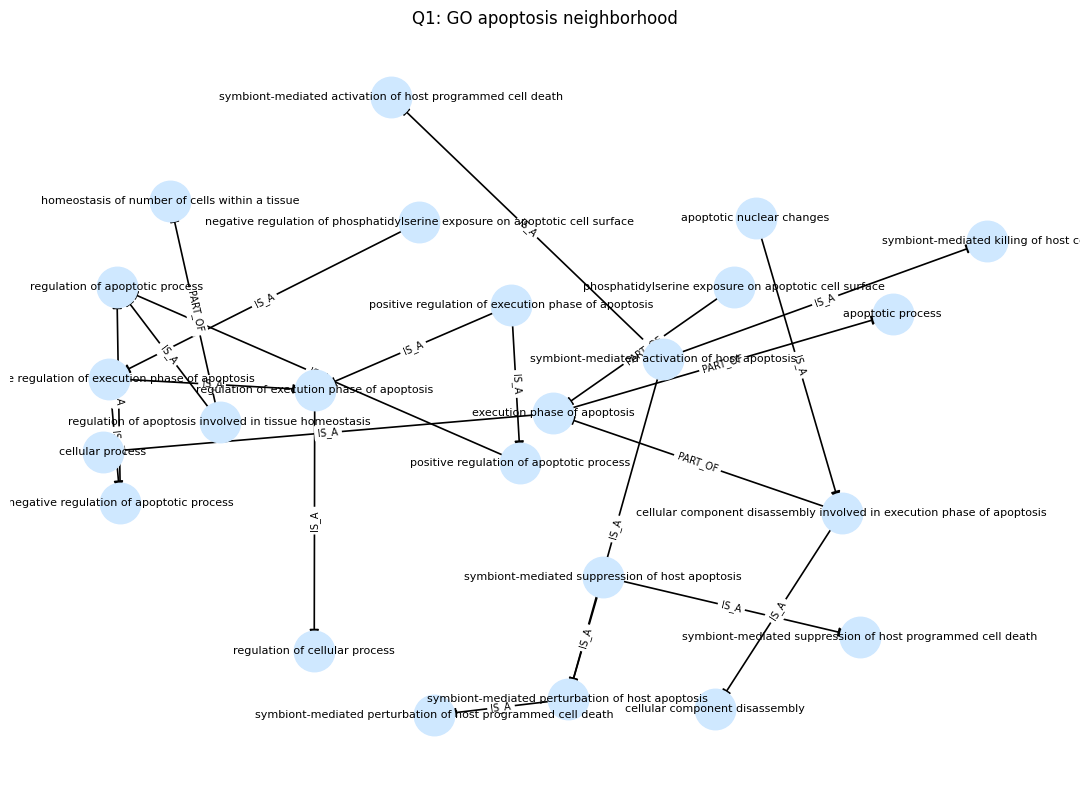

Saved: c:\Users\User\OneDrive\Desktop\TripoDATA\SciGraphRAG\examples\sample_outputs\q1_go_apoptosis.png


In [5]:
q1 = '''
MATCH (a:BiologicalProcess)-[r:IS_A|PART_OF]->(b:BiologicalProcess)
WHERE toLower(a.label) CONTAINS 'apopt'
RETURN a.label AS source, type(r) AS rel, b.label AS target
LIMIT 120
'''
print(q1)
df1 = run_query(q1)
display(df1.head(20))
draw_graph(df1.dropna(), 'source', 'target', 'rel', 'Q1: GO apoptosis neighborhood', 'q1_go_apoptosis.png')

## Requête 2 — Pathways liés à apoptosis

In [ ]:
q2 = '''
MATCH (pw:Pathway)
WHERE toLower(pw.name) CONTAINS 'apopt'
OPTIONAL MATCH (p:Protein)-[r:PARTICIPATES_IN]->(pw)
RETURN p.name AS source, type(r) AS rel, pw.name AS target
LIMIT 120
'''
print(q2)
df2 = run_query(q2)
display(df2.head(20))
if df2.empty:
    print('No pathway name containing "apopt" exists in the current 20-pathway Reactome subset.')
draw_graph(df2.dropna(), 'source', 'target', 'rel', 'Q2: Pathways related to apoptosis', 'q2_pathways_apoptosis.png')


MATCH (pw:Pathway)
WHERE toLower(pw.name) CONTAINS 'apopt'
OPTIONAL MATCH (p:Protein)-[r:PARTICIPATES_IN]->(pw)
RETURN p.name AS source, type(r) AS rel, pw.name AS target
LIMIT 120



""


No rows for Q2: Pathways related to apoptosis


## Requête 3 — Protéines participant à un pathway


MATCH (p:Protein)-[r:PARTICIPATES_IN]->(pw:Pathway)
RETURN p.name AS source, type(r) AS rel, pw.name AS target
LIMIT 120



,source,rel,target
0,NRF1,PARTICIPATES_IN,Organelle biogenesis and maintenance
1,PRC1,PARTICIPATES_IN,Organelle biogenesis and maintenance
2,HCF1,PARTICIPATES_IN,Organelle biogenesis and maintenance
3,CYCS,PARTICIPATES_IN,Organelle biogenesis and maintenance
4,DNAJC11,PARTICIPATES_IN,Organelle biogenesis and maintenance
5,HSPA9,PARTICIPATES_IN,Organelle biogenesis and maintenance
6,APOO,PARTICIPATES_IN,Organelle biogenesis and maintenance
7,IMMT,PARTICIPATES_IN,Organelle biogenesis and maintenance
8,MIC13,PARTICIPATES_IN,Organelle biogenesis and maintenance
9,TMEM11,PARTICIPATES_IN,Organelle biogenesis and maintenance


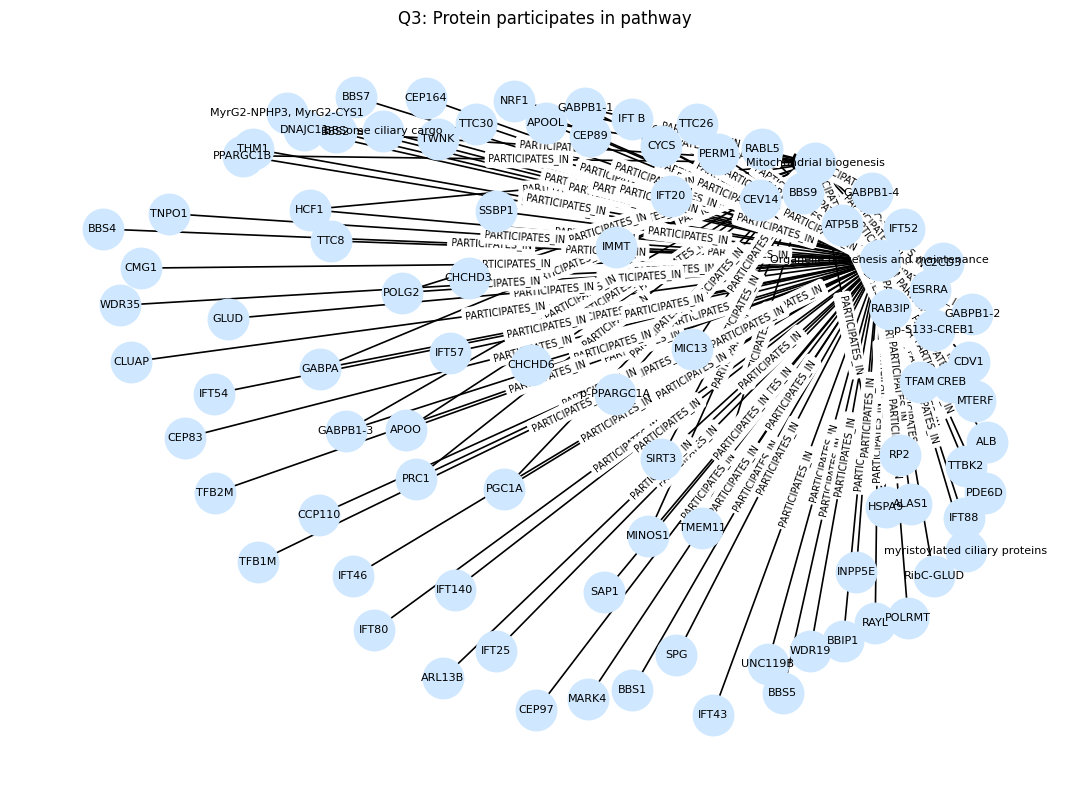

Saved: c:\Users\User\OneDrive\Desktop\TripoDATA\SciGraphRAG\examples\sample_outputs\q3_protein_participates.png


In [8]:
q3 = '''
MATCH (p:Protein)-[r:PARTICIPATES_IN]->(pw:Pathway)
RETURN p.name AS source, type(r) AS rel, pw.name AS target
LIMIT 120
'''
print(q3)
df3 = run_query(q3)
display(df3.head(20))
draw_graph(df3.dropna(), 'source', 'target', 'rel', 'Q3: Protein participates in pathway', 'q3_protein_participates.png')

## Requête 4 — Relations PART_OF


MATCH (a:BiologicalProcess)-[r:PART_OF]->(b:BiologicalProcess)
RETURN a.label AS source, type(r) AS rel, b.label AS target
LIMIT 120



,source,rel,target
0,aminoacyl-tRNA deacylase activity,PART_OF,aminoacyl-tRNA metabolism involved in translat...
1,meiotic DNA repair synthesis involved in recip...,PART_OF,reciprocal meiotic recombination
2,regulation of apoptosis involved in tissue hom...,PART_OF,homeostasis of number of cells within a tissue
3,DNA synthesis involved in UV-damage excision r...,PART_OF,UV-damage excision repair
4,cellular component disassembly involved in exe...,PART_OF,execution phase of apoptosis
5,DNA repair-dependent chromatin remodeling,PART_OF,DNA damage response
6,phosphatidylserine exposure on apoptotic cell ...,PART_OF,execution phase of apoptosis
7,DNA synthesis involved in DNA repair,PART_OF,DNA repair
8,viral DNA repair,PART_OF,viral process
9,execution phase of apoptosis,PART_OF,apoptotic process


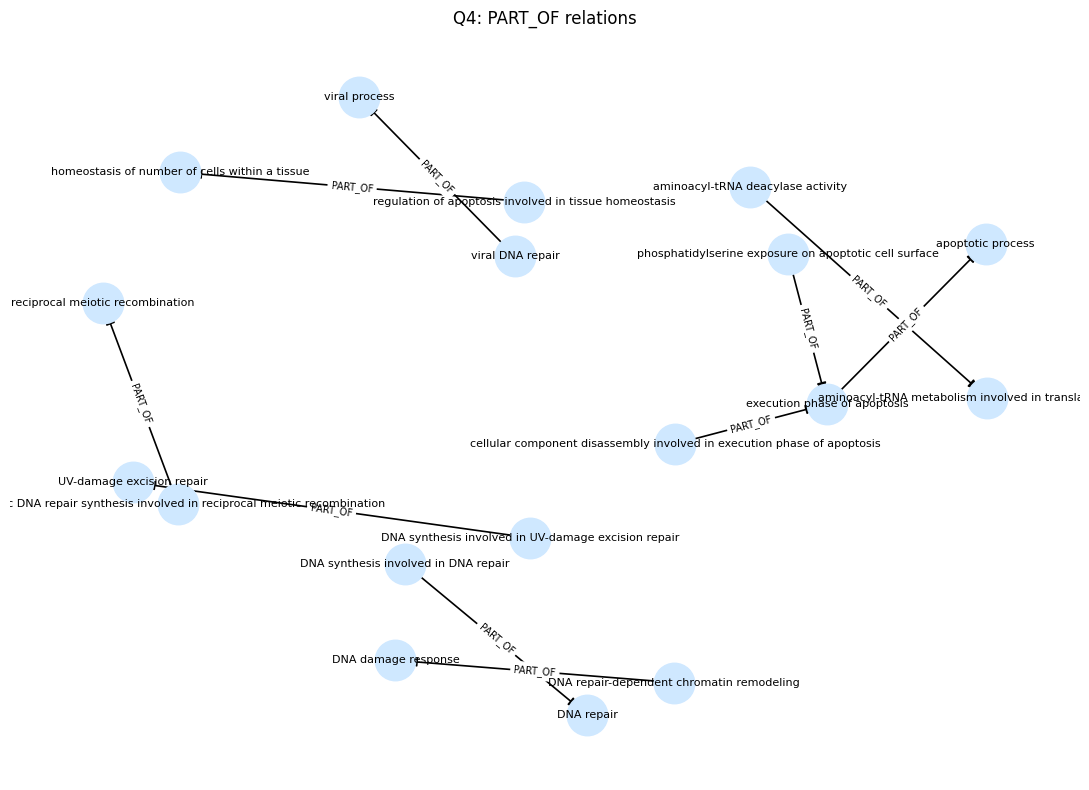

Saved: c:\Users\User\OneDrive\Desktop\TripoDATA\SciGraphRAG\examples\sample_outputs\q4_part_of.png


In [7]:
q4 = '''
MATCH (a:BiologicalProcess)-[r:PART_OF]->(b:BiologicalProcess)
RETURN a.label AS source, type(r) AS rel, b.label AS target
LIMIT 120
'''
print(q4)
df4 = run_query(q4)
display(df4.head(20))
draw_graph(df4.dropna(), 'source', 'target', 'rel', 'Q4: PART_OF relations', 'q4_part_of.png')

## Requête 5 — Relations IS_A


MATCH (a:BiologicalProcess)-[r:IS_A]->(b:BiologicalProcess)
RETURN a.label AS source, type(r) AS rel, b.label AS target
LIMIT 120



,source,rel,target
0,positive regulation of DNA metabolic process,IS_A,regulation of DNA metabolic process
1,meiotic DNA repair synthesis involved in recip...,IS_A,meiotic DNA repair synthesis
2,meiotic DNA repair synthesis,IS_A,meiosis I cell cycle process
3,meiotic DNA repair synthesis,IS_A,DNA synthesis involved in DNA repair
4,positive regulation of mismatch repair,IS_A,positive regulation of DNA repair
5,positive regulation of mismatch repair,IS_A,regulation of mismatch repair
6,regulation of DNA repair,IS_A,regulation of DNA metabolic process
7,regulation of DNA repair,IS_A,regulation of cellular response to stress
8,regulation of nucleotide-excision repair,IS_A,regulation of DNA repair
9,DNA repair complex assembly,IS_A,protein-containing complex assembly


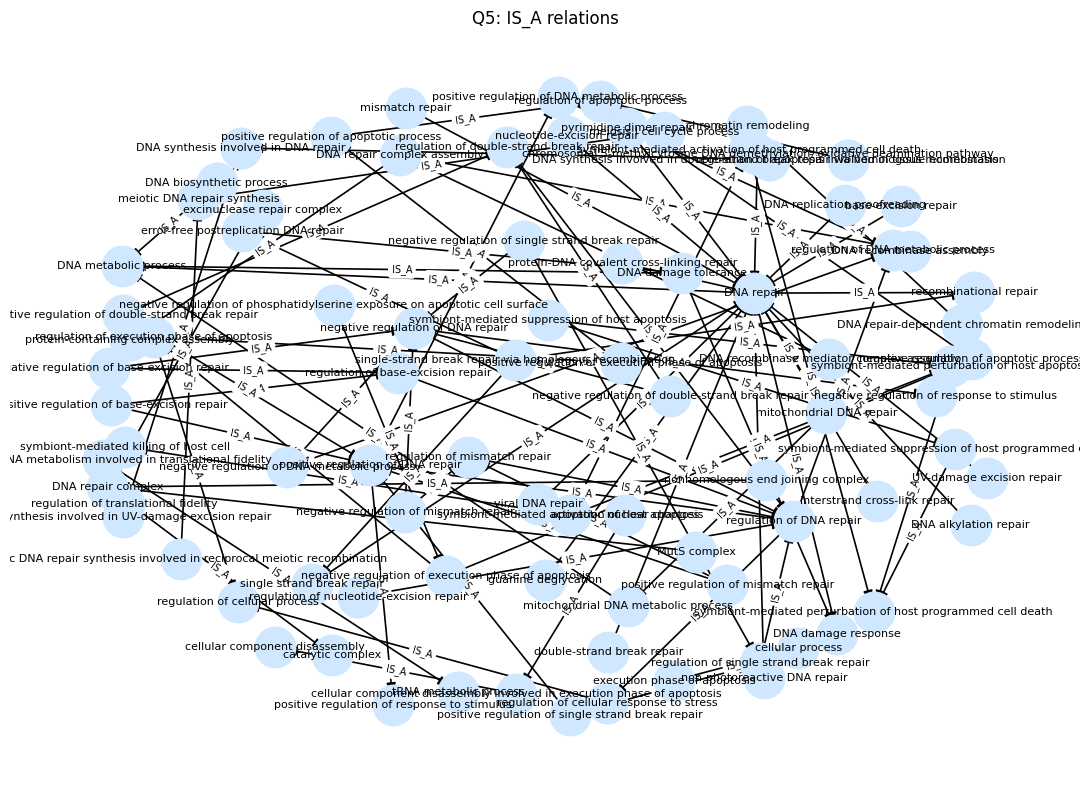

Saved: c:\Users\User\OneDrive\Desktop\TripoDATA\SciGraphRAG\examples\sample_outputs\q5_is_a.png


In [9]:
q5 = '''
MATCH (a:BiologicalProcess)-[r:IS_A]->(b:BiologicalProcess)
RETURN a.label AS source, type(r) AS rel, b.label AS target
LIMIT 120
'''
print(q5)
df5 = run_query(q5)
display(df5.head(20))
draw_graph(df5.dropna(), 'source', 'target', 'rel', 'Q5: IS_A relations', 'q5_is_a.png')

## Captures README (3 images prêtes)

Les 3 captures recommandées pour le README sont:
- `q1_go_apoptosis.png`
- `q3_protein_participates.png`
- `q5_is_a.png`

In [10]:
for name in [
    'q1_go_apoptosis.png',
    'q3_protein_participates.png',
    'q5_is_a.png',
]:
    p = OUTPUT_DIR / name
    print(name, '->', 'OK' if p.exists() else 'MISSING')

client.close()
print('Demo complete.')

q1_go_apoptosis.png -> OK
q3_protein_participates.png -> OK
q5_is_a.png -> OK
Demo complete.
